In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos = {i:s for s,i in stoi.items()}


In [6]:
block_size = 3
X, Y = [], []
for w in words:
    context = [0]*block_size
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context),'---->', itos[ix])
        context = context[1:]+[ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [7]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [8]:
#build the dataset
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0]*block_size
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context),'---->', itos[ix])
            context = context[1:]+[ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [9]:
C = torch.randn((27,2))

In [10]:
emb = C[X]

In [11]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [12]:
h = torch.tanh(emb.view(-1,6) @ W1 +b1)
h


tensor([[ 0.9219, -0.9114,  0.4210,  ..., -0.8593,  0.9594, -0.6716],
        [ 0.8452, -0.6458,  0.2530,  ...,  0.9142,  0.9414,  0.9328],
        [ 0.8261, -0.9945,  0.3672,  ..., -0.9964,  0.9985, -0.9863],
        ...,
        [ 0.8194, -0.9851, -0.8226,  ..., -0.8575,  0.9787,  0.5155],
        [ 0.9505, -0.2372,  0.7617,  ..., -0.0467,  0.9538, -0.9596],
        [ 0.3990, -0.7950,  0.2016,  ...,  0.9767,  0.9015,  0.9986]])

In [13]:
#torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]], 1)
#torch.cat(torch.unbind(emb, 1),1) == emb.view(32,6)

In [14]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [15]:
logits = h @ W2 + b2

In [16]:
counts = logits.exp()

In [17]:
probs = counts / counts.sum(1,keepdims=True)

In [19]:
loss=-probs[torch.arange(32),Y].log().mean() # Negative log likelihood loss
loss

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [40]:
#--------------Formatted------------------

In [20]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [59]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10),generator=g)
W1 = torch.randn((30,200),generator=g)
b1 = torch.randn(200,generator=g)
W2 = torch.randn((200,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C,W1,b1,W2,b2]

In [60]:
sum(p.nelement() for p in parameters) # Number of parameters

11897

In [61]:
for p in parameters:
    p.requires_grad = True

In [62]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [64]:
    #counts = logits.exp()
    #prob = counts/ counts.sum(1, keepdims=True)
    #loss = -prob[torch.arange(32), Y].log().mean()
    #loss = F.cross_entropy(logits, Y[ix]) # Optimized way to do the above three lines operation [Fused kernels] [Optimized for Forward/backward pass]

In [65]:
lri = []
lossi = []
stepi = []

In [ ]:

for i in range(50000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0],(32,))

    # Forward Pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) # exp,log,mean, -ve [Negative log likelihood loss]
    
    # Backward Pass
    for p in parameters:
        p.grad=None
    loss.backward()
    
    #update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr*p.grad
    
    # Track Learning Rate
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())


In [41]:
# plt.plot(stepi, lossi)

In [54]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev) # exp,log,mean, -ve [Negative log likelihood loss]
loss    

tensor(2.2371, grad_fn=<NllLossBackward0>)

In [55]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr) # exp,log,mean, -ve [Negative log likelihood loss]
loss  

tensor(2.2296, grad_fn=<NllLossBackward0>)

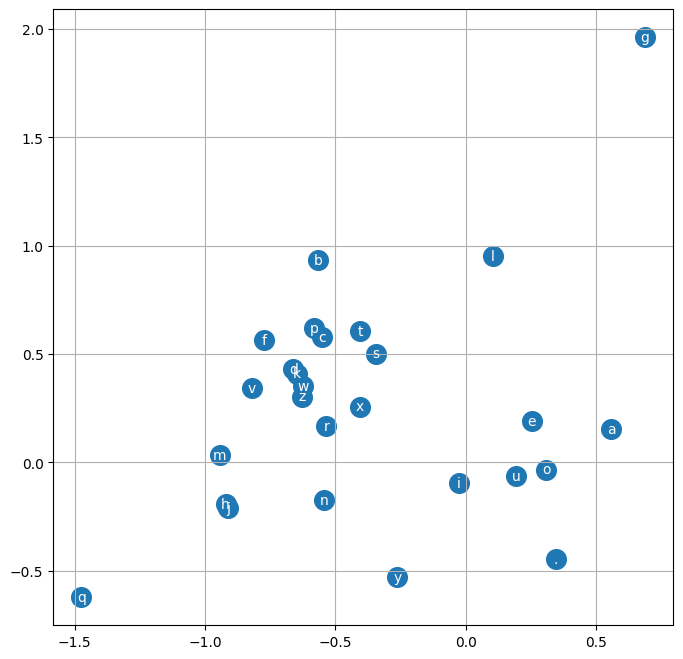

In [56]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha="center",va="center",color="white")
plt.grid("minor")

In [30]:
#dataset should be divided into three splits which are: Training split [Train Parameters], Dev/Validation split [Train Hyperparameters], Test split [Loss evaluation]
# 80%,10%,10%